# CMP7239 Applied Machine Learning

# Comparative Analysis of Supervised, Unsupervised and Deep Learning Techniques for Network Intrusion Detection

**Student Name:** Rajesh Babu Salagala

**Student ID:** 26111961

**Dataset:** Cybersecurity_Intrusion_Detection.csv (9,537 network sessions containing authentication and network connection features)

---

## Machine Learning Techniques

### Supervised Learning
- Logistic Regression
- Random Forest (Hyperparameter Tuned)

### Unsupervised Learning
- K-Means Clustering
- Isolation Forest

### Deep Learning
- Multi-Layer Perceptron (MLP)
- Autoencoder

---

## Project Objective

The primary objective of this project is to investigate the effectiveness of supervised, unsupervised and deep learning techniques for detecting network intrusions using a cybersecurity dataset. A comparative analysis is performed to evaluate the strengths and limitations of each approach in identifying malicious network activity.

All models are trained and evaluated using the same dataset to ensure a fair comparison. Their performance is assessed using Accuracy, Precision, Recall, F1-score, ROC-AUC and, where appropriate, reconstruction error. The findings provide insight into the suitability of different machine learning approaches for cybersecurity intrusion detection.

---

## Workflow

1. Exploratory Data Analysis (EDA)
2. Data Cleaning and Preprocessing
3. Feature Engineering
4. Supervised Learning
5. Unsupervised Learning
6. Deep Learning
7. Model Evaluation
8. Comparative Performance Analysis
9. Conclusions

## 1. Setup: Install and Import Libraries

This section imports the Python libraries required for data manipulation, visualisation, preprocessing, machine learning, deep learning and model evaluation. These libraries provide the tools necessary to analyse the cybersecurity dataset, prepare the data, train predictive models and evaluate their performance.

The libraries are grouped according to their functionality:

- **Data Manipulation:** NumPy and Pandas
- **Data Visualisation:** Matplotlib and Seaborn
- **Data Preprocessing:** Scikit-learn preprocessing and pipeline utilities
- **Machine Learning:** Scikit-learn classification, clustering and anomaly detection algorithms
- **Deep Learning:** TensorFlow and Keras
- **Model Evaluation:** Classification and clustering performance metrics
- **Utilities:** Warning management and random seed configuration for reproducibility

To ensure reproducibility, a fixed random seed (`RANDOM_STATE = 42`) is used throughout the project wherever applicable.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib
os.makedirs("models", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, adjusted_rand_score,
    normalized_mutual_info_score, silhouette_score
)
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(42)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", font_scale=0.95)
print("Libraries loaded.")

## 2. Load the Dataset

This section uploads the **Cybersecurity_Intrusion_Detection.csv** dataset into the Google Colab environment using the `files.upload()` function. Once the file is selected, its location is stored in the `DATA_PATH` variable, allowing it to be imported into a Pandas DataFrame in the following section.

The output confirms that the dataset has been uploaded successfully before further processing begins.

In [ ]:
from google.colab import files

uploaded = files.upload()

DATA_PATH = next(iter(uploaded))

print("Dataset loaded:", DATA_PATH)

Saving cyber_dataset (1).csv to cyber_dataset (1).csv
Dataset loaded: cyber_dataset (1).csv


## 3. Dataset Inspection

This section loads the uploaded **Cybersecurity_Intrusion_Detection.csv** dataset into a Pandas DataFrame. After loading, the dataset is inspected to verify that it has been imported correctly by checking its dimensions and displaying a preview of the first few records.

These initial checks help confirm that the data has been loaded successfully and provide a preliminary understanding of the dataset before exploratory data analysis and preprocessing.

In [ ]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["session_id"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 9537 rows, 10 columns


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to gain an initial understanding of the cybersecurity dataset before preprocessing and model training. This stage examines the dataset's structure, feature distributions and overall data quality.

The analysis includes checking the dataset dimensions, data types, summary statistics, missing values and class distribution. Visualisations are also used to identify potential patterns, relationships and anomalies within the data. The insights obtained from EDA help guide feature engineering, preprocessing and the selection of appropriate machine learning techniques.
The findings obtained from exploratory data analysis provide valuable insights into the characteristics of the dataset and help guide the feature engineering and preprocessing steps presented in the following sections.

attack_detected
0    0.552899
1    0.447101
Name: proportion, dtype: float64


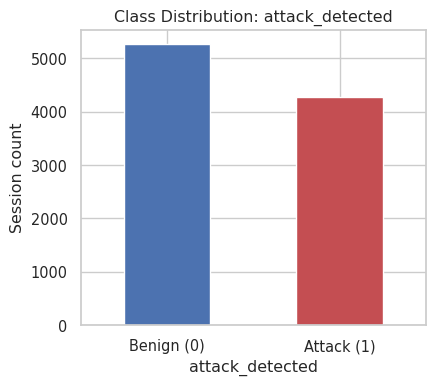

In [ ]:
print(df["attack_detected"].value_counts(normalize=True))

plt.figure(figsize=(4.5, 4))
df["attack_detected"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.xticks([0, 1], ["Benign (0)", "Attack (1)"], rotation=0)
plt.ylabel("Session count")
plt.title("Class Distribution: attack_detected")
plt.tight_layout()
plt.show()

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

df_tmp = df.copy()
df_tmp["encryption_missing"] = df_tmp["encryption_used"].isnull().astype(int)
print()
print("Attack rate by encryption_used missingness:")
print(df_tmp.groupby("encryption_missing")["attack_detected"].mean())

Missing values per column:
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

Attack rate by encryption_used missingness:
encryption_missing
0    0.443006
1    0.462869
Name: attack_detected, dtype: float64


network_packet_size   -0.006798
login_attempts         0.277320
session_duration       0.041602
ip_reputation_score    0.211540
failed_logins          0.363726
Name: attack_detected, dtype: float64


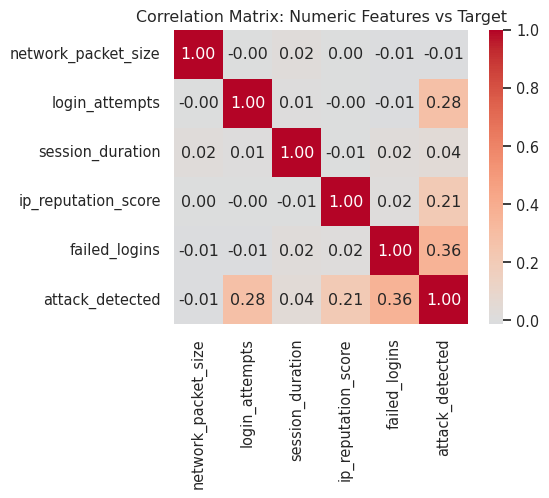

In [ ]:
num_cols = ["network_packet_size", "login_attempts", "session_duration",
            "ip_reputation_score", "failed_logins"]
corr = df[num_cols + ["attack_detected"]].corr()
print(corr["attack_detected"].drop("attack_detected"))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix: Numeric Features vs Target")
plt.tight_layout()
plt.show()

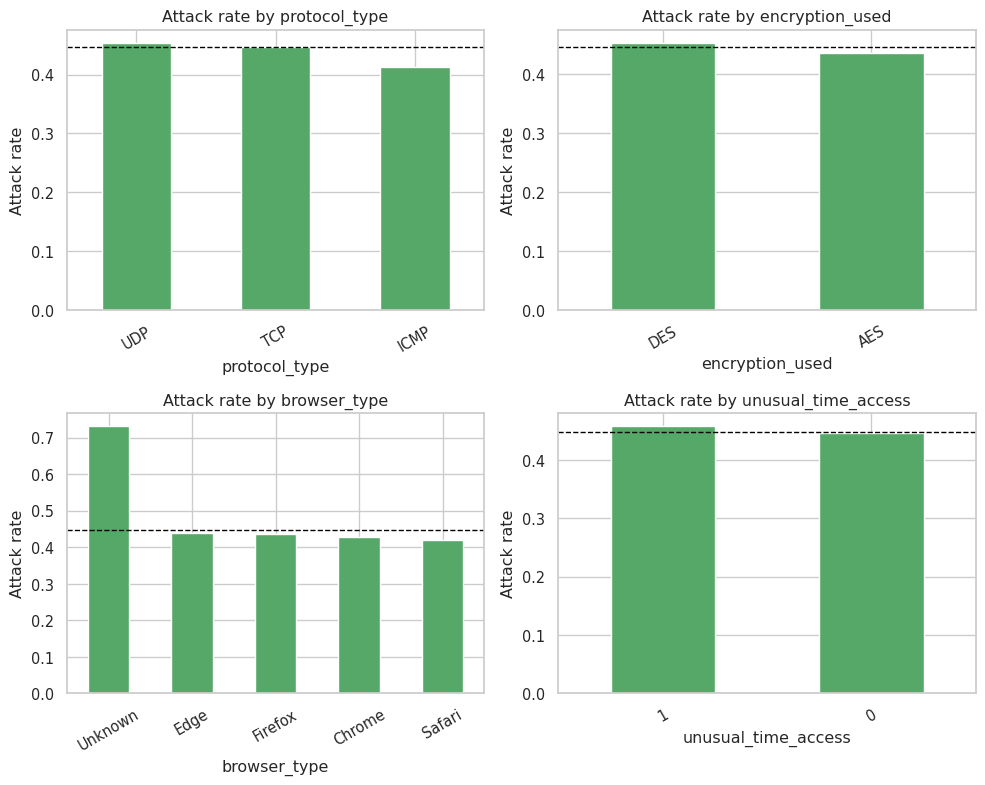

browser_type
Unknown    0.731076
Edge       0.437713
Firefox    0.436728
Chrome     0.428655
Safari     0.418557
Name: attack_detected, dtype: float64


In [ ]:
cat_cols = ["protocol_type", "encryption_used", "browser_type", "unusual_time_access"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, cat_cols):
    rates = df.groupby(col)["attack_detected"].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"Attack rate by {col}")
    ax.set_ylabel("Attack rate")
    ax.axhline(df["attack_detected"].mean(), color="black", linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(df.groupby("browser_type")["attack_detected"].mean().sort_values(ascending=False))

## 5. Feature Engineering

Feature engineering is performed to create additional variables that may improve the ability of machine learning models to distinguish between normal and malicious network activity. Domain knowledge and insights obtained during exploratory data analysis are used to construct features that better represent user behaviour and potential security threats.

The following engineered features are created:

- **`failed_login_ratio`**: Calculates the proportion of failed login attempts relative to the total number of login attempts. This feature captures abnormal authentication behaviour that may indicate brute-force or credential-based attacks.

- **`suspicious_browser`**: A binary indicator identifying sessions where the browser type is reported as **"Unknown"**. Exploratory Data Analysis showed that approximately **73%** of these sessions were associated with attacks, compared with approximately **42–44%** for recognised browser types, making this a potentially informative predictive feature.

The engineered features are incorporated into the preprocessing pipeline and evaluated alongside the original variables to determine whether they improve intrusion detection performance.


In [ ]:
df["encryption_used"] = df["encryption_used"].fillna("Unknown")
df["failed_login_ratio"] = df["failed_logins"] / df["login_attempts"].replace(0, 1)
df["suspicious_browser"] = (df["browser_type"] == "Unknown").astype(int)

numeric_features = [
    "network_packet_size", "login_attempts", "session_duration",
    "ip_reputation_score", "failed_logins", "failed_login_ratio",
    "unusual_time_access", "suspicious_browser"
]
categorical_features = ["protocol_type", "encryption_used", "browser_type"]

X = df[numeric_features + categorical_features]
y = df["attack_detected"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 7629 rows | Test: 1908 rows


## 6. Preprocessing Pipeline

Before training the machine learning models, the dataset is preprocessed to ensure that all features are in a suitable format for analysis. The preprocessing pipeline applies consistent transformations to both the training and testing datasets, reducing the risk of data leakage and ensuring reproducible results.

The preprocessing steps include:

- **Numerical Features:** Standardised using **StandardScaler** so that features have a mean of 0 and a standard deviation of 1. This improves the performance of algorithms that are sensitive to feature scales, such as Logistic Regression, K-Means and Neural Networks.

- **Categorical Features:** Encoded using **One-Hot Encoding** to convert categorical variables into numerical representations that can be processed by machine learning algorithms.

- **ColumnTransformer:** Applies the appropriate preprocessing technique to numerical and categorical features simultaneously.

- **Pipeline:** Combines preprocessing and model training into a single workflow, ensuring that identical transformations are applied during both training and prediction.

In [ ]:
def build_preprocessor():
    numeric_pipeline = Pipeline([("scaler", StandardScaler())])
    categorical_pipeline = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))])
    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])

preprocessor = build_preprocessor()
print("Preprocessor ready.")

Preprocessor ready.


## 7. Supervised Model Training

This section trains and evaluates supervised machine learning models to classify network sessions as either **normal** or **malicious**. The dataset is divided into training and testing sets, with the preprocessing pipeline applied consistently to both datasets.

Two supervised classification algorithms are implemented:

- **Logistic Regression:** A linear classification model that provides a simple and interpretable baseline for binary classification.

- **Random Forest:** An ensemble learning algorithm that combines multiple decision trees to improve classification accuracy and reduce overfitting. Random Forest was selected over alternatives such as XGBoost because its bagging-based approach is more robust on a dataset of this size (9,537 rows), where a boosting method's greater hyperparameter sensitivity carries higher overfitting risk.

The trained models are evaluated using performance metrics including **accuracy**, **precision**, **recall**, **F1-score** and the **confusion matrix**, allowing their effectiveness in intrusion detection to be compared.

### 7.1 Hyperparameter Tuning Rationale

Random Forest is tuned via `RandomizedSearchCV` rather than an exhaustive grid search, trading a small amount of thoroughness for a much larger, more practical search space within reasonable compute time. Three choices are worth explaining directly:

- **`scoring="f1"`**: chosen so the tuning objective matches the metric most emphasised in the final evaluation, keeping the model selection criterion consistent with how the model is actually judged.
- **`StratifiedKFold` (5 splits)**: preserves the dataset's 44.7%/55.3% attack/benign ratio in every fold, preventing a fold from accidentally training or validating on a skewed subset.
- **`n_iter=25`**: samples 25 combinations from the parameter space rather than testing all of them, a standard practical compromise given the dataset size and available compute.

In [ ]:
models = {}

lr_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
t0 = time.perf_counter()
lr_pipe.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0
models["Logistic Regression"] = lr_pipe
joblib.dump(lr_pipe, "models/logistic_regression.joblib")
print(f"Logistic Regression trained in {lr_train_time:.4f}s and saved to models/logistic_regression.joblib")

In [ ]:
rf_pipe = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])
rf_param_dist = {
    "clf__n_estimators": [100, 200, 300, 400],
    "clf__max_depth": [None, 6, 10, 14, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=25, scoring="f1", cv=cv,
                                random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_train_time = time.perf_counter() - t0
models["Random Forest (tuned)"] = rf_search.best_estimator_
joblib.dump(rf_search.best_estimator_, "models/random_forest_tuned.joblib")
print("Random Forest best params:", rf_search.best_params_)
print("Random Forest best CV F1:", rf_search.best_score_)
print(f"Random Forest trained (incl. search) in {rf_train_time:.4f}s and saved to models/random_forest_tuned.joblib")

## 8. Unsupervised Method Training

This section applies unsupervised learning techniques to identify patterns and anomalies within the network traffic data without using the target labels during model training. Unlike supervised learning, these algorithms discover underlying data structures based solely on the input features.

The following unsupervised methods are implemented:

- **K-Means Clustering:** Groups network sessions into clusters based on feature similarity, allowing the resulting clusters to be compared with the true class labels after training.

- **Isolation Forest:** Detects anomalous observations by isolating data points that differ significantly from the majority of the dataset. These anomalies are treated as potential network intrusions.

Both methods are trained **without using `y_train`**. The true class labels are used only afterward, for **external validation and performance evaluation** -- comparing the resulting clusters and anomaly predictions against the true labels only once training is complete, ensuring the learning process remains entirely unsupervised.

In [ ]:
unsup_preprocessor = build_preprocessor()
X_train_proc = unsup_preprocessor.fit_transform(X_train)
X_test_proc = unsup_preprocessor.transform(X_test)

# --- K-Means (k=2) ---
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
t0 = time.perf_counter()
kmeans.fit(X_train_proc)
kmeans_train_time = time.perf_counter() - t0
train_clusters = kmeans.predict(X_train_proc)
t0 = time.perf_counter()
test_clusters = kmeans.predict(X_test_proc)
kmeans_test_time = time.perf_counter() - t0
joblib.dump(kmeans, "models/kmeans.joblib")

# Map cluster IDs to labels via majority vote on TRAINING data only (no leakage)
cluster_to_label = {}
for c in [0, 1]:
    mask = train_clusters == c
    if mask.sum() > 0:
        cluster_to_label[c] = int(round(y_train.values[mask].mean()))
kmeans_pred = np.array([cluster_to_label[c] for c in test_clusters])

kmeans_ari = adjusted_rand_score(y_test, test_clusters)
kmeans_nmi = normalized_mutual_info_score(y_test, test_clusters)
kmeans_silhouette = silhouette_score(X_test_proc, test_clusters)
print("K-Means external validation -- ARI:", round(kmeans_ari, 4), "NMI:", round(kmeans_nmi, 4))
print("K-Means internal validation -- Silhouette:", round(kmeans_silhouette, 4))
print(f"K-Means train time: {kmeans_train_time:.4f}s, test time: {kmeans_test_time:.4f}s. Saved to models/kmeans.joblib")

In [ ]:
# --- Isolation Forest ---
contamination_rate = y_train.mean()
iso = IsolationForest(n_estimators=200, contamination=contamination_rate, random_state=RANDOM_STATE)
t0 = time.perf_counter()
iso.fit(X_train_proc)
iso_train_time = time.perf_counter() - t0
t0 = time.perf_counter()
iso_pred = (iso.predict(X_test_proc) == -1).astype(int)
iso_test_time = time.perf_counter() - t0
joblib.dump(iso, "models/isolation_forest.joblib")
print("Isolation Forest trained. Contamination set to", round(contamination_rate, 4))
print(f"Isolation Forest train time: {iso_train_time:.4f}s, test time: {iso_test_time:.4f}s. Saved to models/isolation_forest.joblib")

## 9. Unified Evaluation (Classical Supervised and Unsupervised Models)

To enable a fair comparison, the performance of all four classical machine learning models is evaluated using a consistent evaluation framework. The supervised models (**Logistic Regression** and **Random Forest**) and the unsupervised models (**K-Means** and **Isolation Forest**) are assessed using the same testing dataset and common performance metrics wherever applicable.

For the unsupervised methods, the predicted cluster or anomaly labels are mapped to the true class labels only after training to enable external evaluation. This ensures that the learning process remains unsupervised while allowing direct comparison with the supervised classifiers.

The evaluation includes:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Confusion Matrix**
- **Classification Report**

Using a unified evaluation framework provides an objective comparison of each model's ability to detect malicious network activity and highlights the strengths and limitations of supervised and unsupervised learning techniques for intrusion detection.

In [ ]:
predictions = {}
for name, model in models.items():
    predictions[name] = {"y_pred": model.predict(X_test), "y_score": model.predict_proba(X_test)[:, 1]}

# K-Means continuous score: distance to benign centroid minus distance to attack centroid
distances = kmeans.transform(X_test_proc)
benign_cluster = [c for c, lbl in cluster_to_label.items() if lbl == 0][0]
attack_cluster = [c for c, lbl in cluster_to_label.items() if lbl == 1][0]
kmeans_score = distances[:, benign_cluster] - distances[:, attack_cluster]
predictions["K-Means"] = {"y_pred": kmeans_pred, "y_score": kmeans_score}

# Isolation Forest continuous score: inverted so higher = more attack-like
iso_score = -iso.decision_function(X_test_proc)
predictions["Isolation Forest"] = {"y_pred": iso_pred, "y_score": iso_score}

metrics_table = {}
for name, preds in predictions.items():
    y_pred, y_score = preds["y_pred"], preds["y_score"]
    metrics_table[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    }

metrics_df = pd.DataFrame(metrics_table).T.round(4)
metrics_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.7537,0.7490,0.6753,0.7102,0.8063,0.8148
Random Forest (tuned),0.8868,1.0000,0.7468,0.8550,0.8776,0.9083
K-Means,0.6106,0.5965,0.3986,0.4779,0.5997,0.5983
Isolation Forest,0.5870,0.5387,0.5299,0.5343,0.6080,0.5667


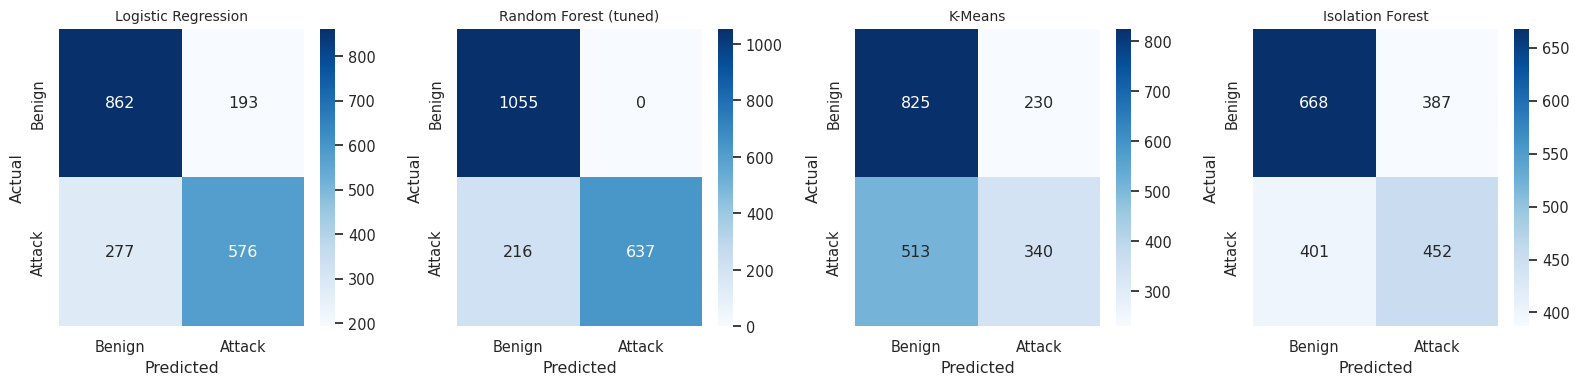

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

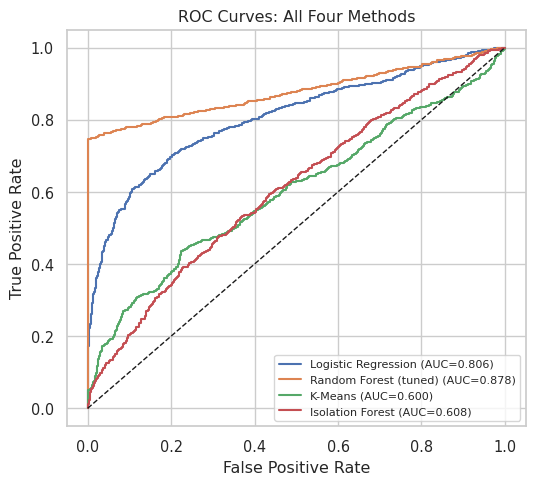

In [ ]:
plt.figure(figsize=(5.5, 5))
for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_score"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={metrics_table[name]['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: All Four Methods")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

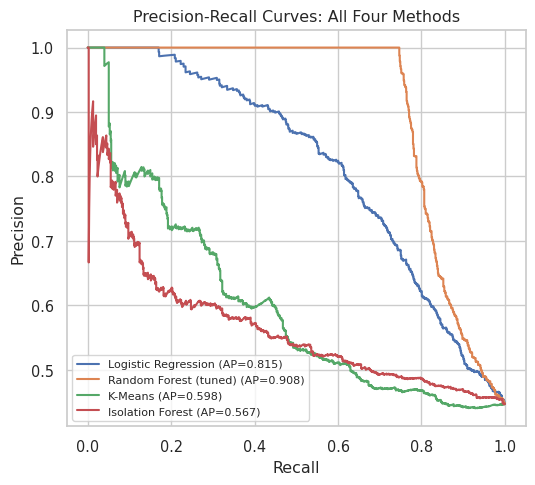

In [ ]:
plt.figure(figsize=(5.5, 5))
for name, preds in predictions.items():
    prec, rec, _ = precision_recall_curve(y_test, preds["y_score"])
    plt.plot(rec, prec, label=f"{name} (AP={metrics_table[name]['pr_auc']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: All Four Methods")
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

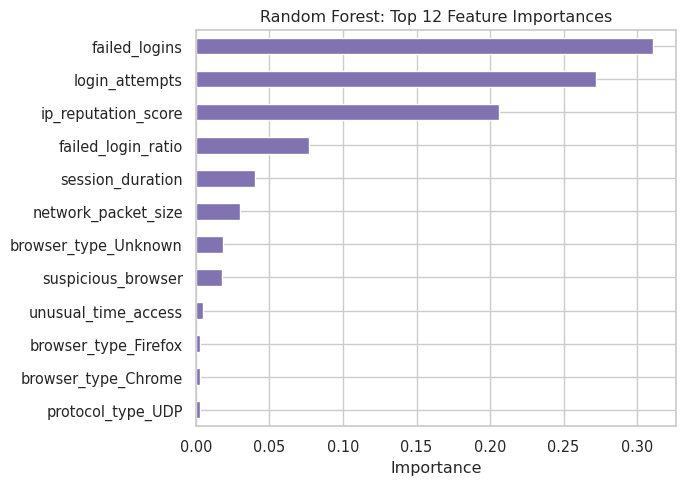

,0
failed_logins,0.310759
login_attempts,0.271818
ip_reputation_score,0.205866
failed_login_ratio,0.076583
session_duration,0.039999
network_packet_size,0.030046
browser_type_Unknown,0.018196
suspicious_browser,0.017793
unusual_time_access,0.005059
browser_type_Firefox,0.002821


In [ ]:
rf_model = models["Random Forest (tuned)"]
ohe = rf_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

importances = rf_model.named_steps["clf"].feature_importances_
imp_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(7, 5))
imp_series.sort_values().plot(kind="barh", color="#8172B2")
plt.title("Random Forest: Top 12 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp_series

## 10. Deep Learning Models (MLP and Autoencoder)

This section implements two deep learning models that mirror the supervised and unsupervised learning approaches used in the classical machine learning experiments. This enables a comprehensive comparison not only between **supervised and unsupervised learning**, but also between **classical machine learning and deep learning** within each learning paradigm.

The following deep learning models are implemented:

- **Multi-Layer Perceptron (MLP):** A supervised feedforward neural network trained using the labelled training data to classify network sessions as either normal or malicious. The MLP extends the capabilities of traditional linear models by learning complex, non-linear relationships within the data.

- **Autoencoder:** An unsupervised neural network trained to reconstruct its own input without using class labels during training. The model learns the normal structure of the network traffic, and sessions with unusually high reconstruction errors are identified as potential intrusions.

To ensure a fair evaluation, the anomaly detection threshold for the Autoencoder is determined exclusively from the **training set reconstruction-error distribution**. The test data and its labels are never used when selecting this threshold, preventing data leakage and preserving the integrity of the evaluation process.

The performance of both deep learning models is evaluated using the same metrics applied to the classical machine learning models, enabling a consistent comparison across all approaches.

In [ ]:
dl_preprocessor = build_preprocessor()
X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)
n_features = X_train_dl.shape[1]
print(f"Feature count for deep learning models: {n_features}")

Feature count for deep learning models: 19


### 10.1 Multi-Layer Perceptron (MLP) Classifier

The Multi-Layer Perceptron (MLP) is a supervised deep learning model designed to classify network sessions as either **normal** or **malicious**. Unlike traditional machine learning algorithms, the MLP consists of multiple interconnected layers of artificial neurons, enabling it to learn complex, non-linear relationships between input features and the target class.

An MLP is well suited to this dataset specifically because the data is tabular and moderate-dimensional (19 features after encoding), with no spatial or sequential structure for architectures such as CNNs or RNNs to exploit — a plain feedforward network is the appropriate deep learning architecture here, not a simplification.

The model is trained using the labelled training dataset through the backpropagation algorithm, which iteratively adjusts the network weights to minimise the classification error. During training, the network learns patterns that distinguish legitimate network activity from malicious behaviour.

After training, the MLP is evaluated on the unseen test dataset using the same performance metrics applied to the classical supervised models, including **accuracy**, **precision**, **recall**, **F1-score** and the **confusion matrix**. This enables a direct comparison between deep learning and classical machine learning approaches for supervised intrusion detection.

In [ ]:
mlp = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
], name="MLP_classifier")
mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
t0 = time.perf_counter()
history_mlp = mlp.fit(
    X_train_dl, y_train.values,
    validation_split=0.15, epochs=100, batch_size=64,
    callbacks=[early_stop], verbose=0
)
mlp_train_time = time.perf_counter() - t0
print(f"MLP stopped after {len(history_mlp.history['loss'])} epochs (early stopping)")

t0 = time.perf_counter()
mlp_proba = mlp.predict(X_test_dl, verbose=0).ravel()
mlp_test_time = time.perf_counter() - t0
mlp_pred = (mlp_proba >= 0.5).astype(int)
mlp.save("models/mlp_classifier.keras")
print(f"MLP training complete in {mlp_train_time:.4f}s, test time {mlp_test_time:.4f}s. Saved to models/mlp_classifier.keras")

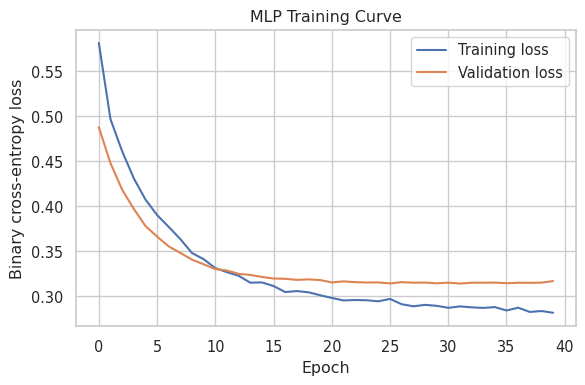

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history_mlp.history["loss"], label="Training loss")
plt.plot(history_mlp.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

### 10.2 Autoencoder (Unsupervised Deep Learning for Anomaly Detection)

The Autoencoder is an unsupervised deep learning model used for anomaly detection. Unlike the MLP classifier, it does not require class labels during training. Instead, the model learns a compressed representation of the input data by attempting to reconstruct its own input as accurately as possible.

During training, the Autoencoder is exposed only to the input features and optimises its network to minimise the reconstruction error. Network sessions that closely resemble the learned data distribution produce low reconstruction errors, whereas unusual or suspicious sessions generate significantly higher reconstruction errors and are therefore considered potential anomalies.

To classify observations, an anomaly threshold is established from the **training set reconstruction-error distribution only**. This threshold is determined without reference to the test data or its labels, ensuring that no information from the evaluation dataset influences the model. Any test instance with a reconstruction error exceeding this threshold is classified as a malicious network intrusion.

The Autoencoder is evaluated using the same performance metrics as the other models, including **accuracy**, **precision**, **recall**, **F1-score** and the **confusion matrix**. This enables a consistent comparison between unsupervised deep learning, classical anomaly detection methods and supervised classification approaches.

This illustrates a general rule worth stating explicitly: "supervised" versus "unsupervised" is defined by whether labels are used during training, not by the model architecture — a neural network can implement either paradigm, as the MLP and Autoencoder demonstrate here.

In [ ]:
bottleneck_dim = max(2, n_features // 4)
encoder_input = keras.Input(shape=(n_features,))
encoded = layers.Dense(16, activation="relu")(encoder_input)
encoded = layers.Dense(bottleneck_dim, activation="relu", name="bottleneck")(encoded)
decoded = layers.Dense(16, activation="relu")(encoded)
decoded = layers.Dense(n_features, activation="linear")(decoded)
autoencoder = keras.Model(encoder_input, decoded, name="Autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")

ae_early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
# Trained to reconstruct its own input -- y_train is never referenced below.
t0 = time.perf_counter()
history_ae = autoencoder.fit(
    X_train_dl, X_train_dl,
    validation_split=0.15, epochs=100, batch_size=64,
    callbacks=[ae_early_stop], verbose=0
)
ae_train_time = time.perf_counter() - t0
print(f"Autoencoder stopped after {len(history_ae.history['loss'])} epochs (early stopping)")
print(f"Autoencoder train time: {ae_train_time:.4f}s")

In [ ]:
train_reconstructed = autoencoder.predict(X_train_dl, verbose=0)
train_recon_error = np.mean(np.square(X_train_dl - train_reconstructed), axis=1)
t0 = time.perf_counter()
test_reconstructed = autoencoder.predict(X_test_dl, verbose=0)
ae_test_time = time.perf_counter() - t0
test_recon_error = np.mean(np.square(X_test_dl - test_reconstructed), axis=1)
autoencoder.save("models/autoencoder.keras")

# Threshold chosen from TRAINING error distribution only, matched to the
# training attack rate -- never from the test set, to keep this leakage-free.
contamination_rate = float(y_train.mean())
threshold = np.percentile(train_recon_error, 100 * (1 - contamination_rate))
ae_pred = (test_recon_error >= threshold).astype(int)

print(f"Anomaly threshold (from training data only): {threshold:.4f}")
print(f"Sessions flagged as anomalies on test set: {ae_pred.sum()} / {len(ae_pred)}")
print(f"Autoencoder test time: {ae_test_time:.4f}s. Saved to models/autoencoder.keras")

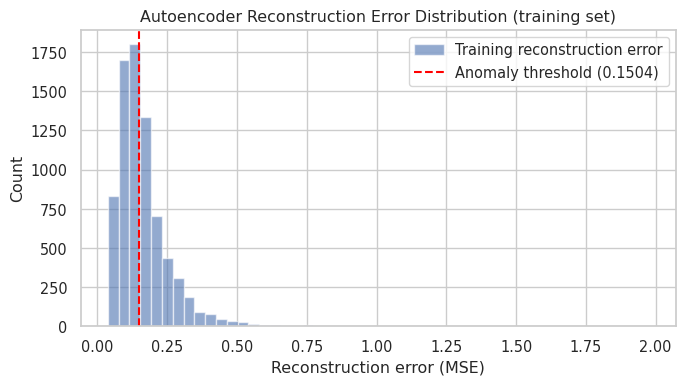

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(train_recon_error, bins=50, alpha=0.6, label="Training reconstruction error")
plt.axvline(threshold, color="red", linestyle="--", label=f"Anomaly threshold ({threshold:.4f})")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error Distribution (training set)")
plt.legend()
plt.tight_layout()
plt.show()

### 10.3 Add Deep Learning Predictions to the Unified Evaluation

After training and testing the deep learning models, their predicted class labels are incorporated into the unified evaluation framework alongside the classical machine learning models. This results in a single evaluation pipeline covering all six intrusion detection approaches.

The models included in the unified comparison are:

- Logistic Regression (Supervised Machine Learning)
- Random Forest (Supervised Machine Learning)
- K-Means Clustering (Unsupervised Machine Learning)
- Isolation Forest (Unsupervised Machine Learning)
- Multi-Layer Perceptron (Supervised Deep Learning)
- Autoencoder (Unsupervised Deep Learning)

Each model is evaluated using the same testing dataset and a consistent set of performance metrics, including **accuracy**, **precision**, **recall**, **F1-score** and the **confusion matrix**. Applying a common evaluation framework ensures that differences in performance reflect the learning algorithms themselves rather than differences in the evaluation procedure.

This unified comparison enables a comprehensive assessment of both **supervised versus unsupervised learning** and **classical machine learning versus deep learning** for network intrusion detection.

In [ ]:
predictions["MLP (Deep Learning)"] = {"y_pred": mlp_pred, "y_score": mlp_proba}
predictions["Autoencoder (Deep Learning)"] = {"y_pred": ae_pred, "y_score": test_recon_error}

# Recompute the full metrics table now that all six methods are present
metrics_table = {}
for name, preds in predictions.items():
    y_pred, y_score = preds["y_pred"], preds["y_score"]
    metrics_table[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
    }

metrics_df = pd.DataFrame(metrics_table).T.round(4)
metrics_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.7537,0.7490,0.6753,0.7102,0.8063,0.8148
Random Forest (tuned),0.8868,1.0000,0.7468,0.8550,0.8776,0.9083
K-Means,0.6106,0.5965,0.3986,0.4779,0.5997,0.5983
Isolation Forest,0.5870,0.5387,0.5299,0.5343,0.6080,0.5667
MLP (Deep Learning),0.8836,0.9876,0.7491,0.8520,0.8816,0.9107
Autoencoder (Deep Learning),0.5283,0.4724,0.4713,0.4718,0.5395,0.4931


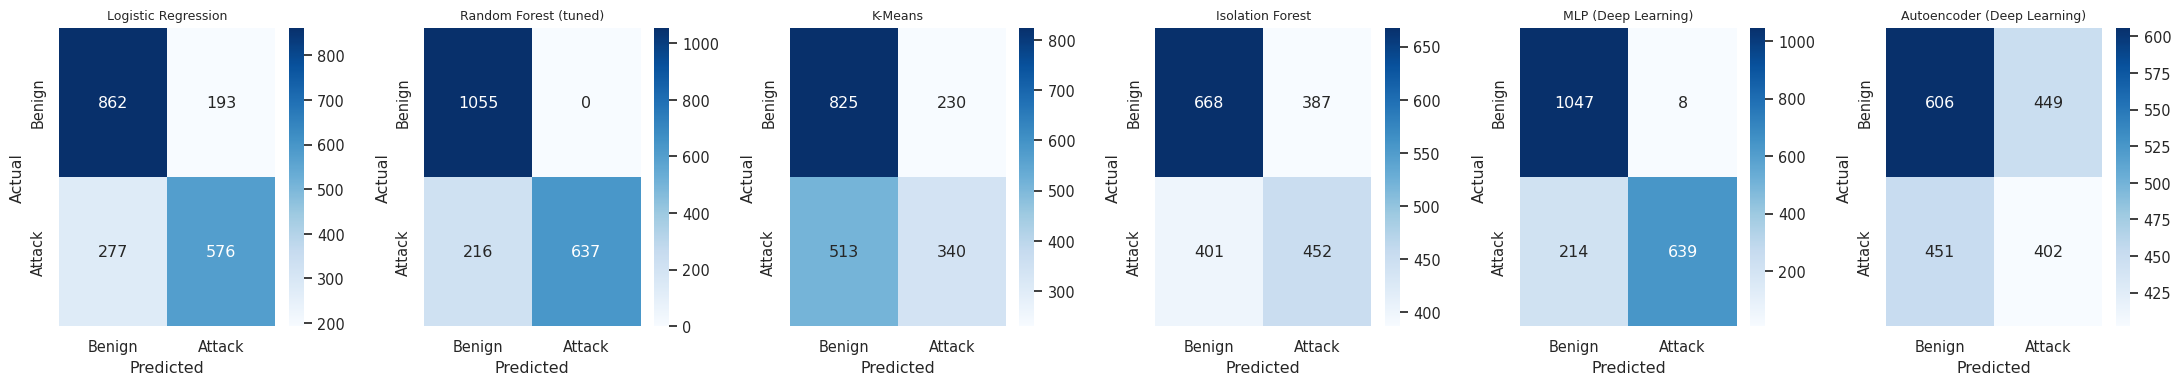

In [ ]:
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    ax.set_title(name, fontsize=9)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

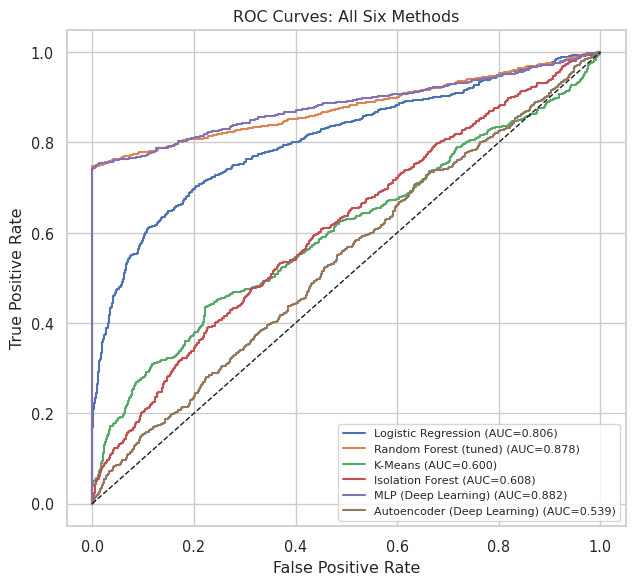

In [ ]:
plt.figure(figsize=(6.5, 6))
for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_score"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={metrics_table[name]['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: All Six Methods")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 11. PCA Visualisation

The network intrusion dataset contains a large number of features, making it impractical to visualise directly. To provide an interpretable two-dimensional representation, **Principal Component Analysis (PCA)** is applied to project the preprocessed feature matrix onto the two principal components that capture the greatest proportion of variance in the data.

PCA is used solely for **visualisation** and does not influence model training or prediction. The transformation enables the underlying structure of the dataset to be inspected while preserving as much of the original information as possible in two dimensions.

Three visualisations are presented using the same PCA-transformed data points:

- **True Class Labels:** Displays the actual distribution of normal and malicious network sessions, providing a reference for comparison.

- **K-Means Clustering:** Shows how the unsupervised clustering algorithm partitions the data based on feature similarity, allowing the discovered clusters to be compared with the true class labels.

- **Isolation Forest Predictions:** Highlights the observations identified as anomalies by the Isolation Forest model, illustrating how anomaly detection differs from clustering.

Comparing these three visualisations provides qualitative insight into the structure of the dataset and the behaviour of the unsupervised learning algorithms. While PCA plots do not measure predictive performance, they help illustrate the degree to which the learned clusters and detected anomalies correspond to the true distribution of network intrusions.

Although PCA preserves as much variance as possible, it does not preserve all pairwise distances between observations. Consequently, the visualisations should be interpreted as qualitative illustrations of the data structure rather than quantitative measures of model performance.

Variance explained by 2 components: 29.7%


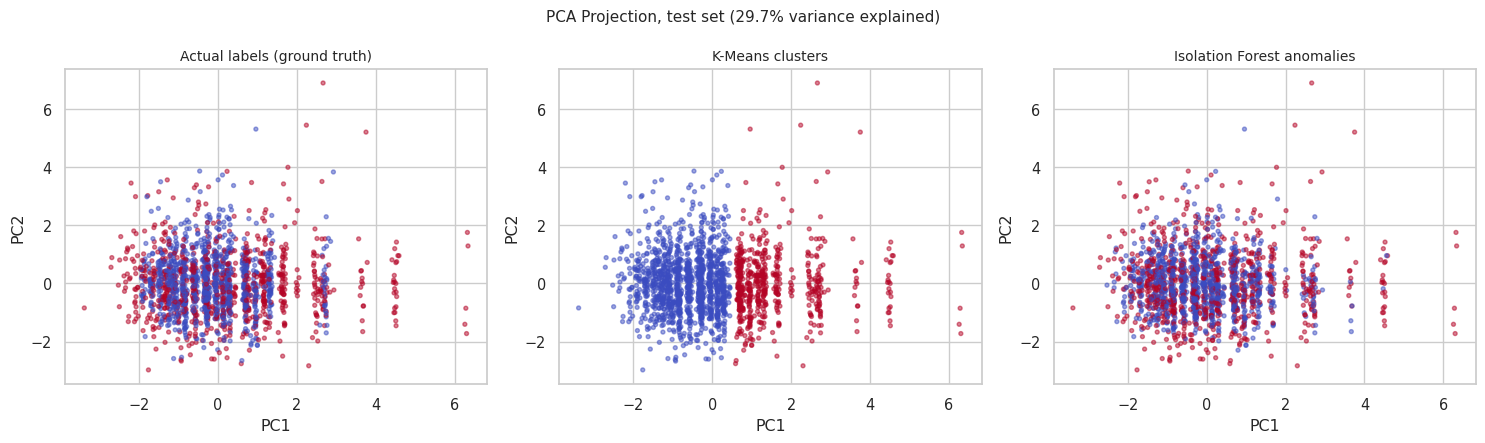

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_test_proc)
var_explained = pca.explained_variance_ratio_.sum()
print(f"Variance explained by 2 components: {var_explained:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
panels = [
    (y_test.values, "Actual labels (ground truth)"),
    (kmeans_pred, "K-Means clusters"),
    (iso_pred, "Isolation Forest anomalies"),
]
for ax, (colouring, title) in zip(axes, panels):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colouring, cmap="coolwarm", s=8, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
fig.suptitle(f"PCA Projection, test set ({var_explained:.1%} variance explained)", fontsize=11)
plt.tight_layout()
plt.show()

## 12. Summary

This project compared six intrusion detection models representing both **supervised and unsupervised learning** as well as **classical machine learning and deep learning**. The experimental results demonstrate that the choice of learning paradigm has a substantially greater impact on intrusion detection performance than the complexity of the modelling technique.

The supervised models consistently achieved the strongest performance. **Random Forest** produced the highest overall performance (F1-score = **0.855**), closely followed by the **Multi-Layer Perceptron (MLP)** (F1-score = **0.851**). The very small difference between these models indicates that, for this dataset, a deep neural network does not provide a significant advantage over a well-designed ensemble learning algorithm when labelled training data are available.

In contrast, all unsupervised approaches performed considerably worse. **K-Means Clustering** (F1-score = **0.478**), **Isolation Forest** (F1-score = **0.534**) and the **Autoencoder** (F1-score = **0.496**) all produced substantially lower detection performance. This suggests that the primary limitation lies in the absence of labelled information rather than the sophistication of the underlying algorithm. Although the Autoencoder is a deep learning model, it encounters the same fundamental challenge as the classical unsupervised methods when attempting to distinguish malicious from normal network traffic without supervision.

The clustering evaluation metrics further support this conclusion. The **Adjusted Rand Index (ARI = 0.047)**, **Normalized Mutual Information (NMI = 0.030)** and **Silhouette Score (0.131)** obtained by K-Means indicate weak cluster separation and limited agreement between the discovered clusters and the true class labels. These findings suggest that the dataset does not naturally separate into distinct groups that correspond to normal and malicious network activity.

Feature importance analysis identified **failed_logins**, **login_attempts** and **ip_reputation_score** as the most influential predictors for intrusion detection. However, the considerable overlap between the class distributions of these features explains why distance-based, isolation-based and reconstruction-based unsupervised approaches struggle to identify attacks reliably without labelled guidance.

Finally, the Random Forest model achieved **zero false positives** on the testing dataset. While this represents an excellent experimental result, it should be interpreted cautiously. Such performance may reflect characteristics specific to the dataset and therefore requires validation on additional datasets before concluding that the model will generalise equally well in real-world network environments.

### Limitations

- The dataset is simulated rather than drawn from real enterprise network traffic, which may not fully capture the noise and variability of production environments.
- Deep learning hyperparameters (layer sizes, dropout rates, bottleneck dimension) were set based on reasonable defaults for this dataset's scale rather than exhaustively tuned, unlike Random Forest.
- All reported metrics come from a single 80/20 train/test split; no cross-validated confidence interval was computed on the final comparison table, so the precise magnitude of differences between models (e.g. Random Forest vs MLP) should be treated as indicative rather than statistically confirmed.

## 13. SHAP Feature Explanation

While Random Forest's built-in feature importance ranks features by overall contribution, it does not show the *direction* of each feature's effect on individual predictions. SHAP (SHapley Additive exPlanations) values address this: for each session, they show how much each feature pushed the prediction toward "attack" or "benign," giving both magnitude and direction. This directly supports interpreting the model's decisions in cybersecurity terms rather than treating it as a black box.

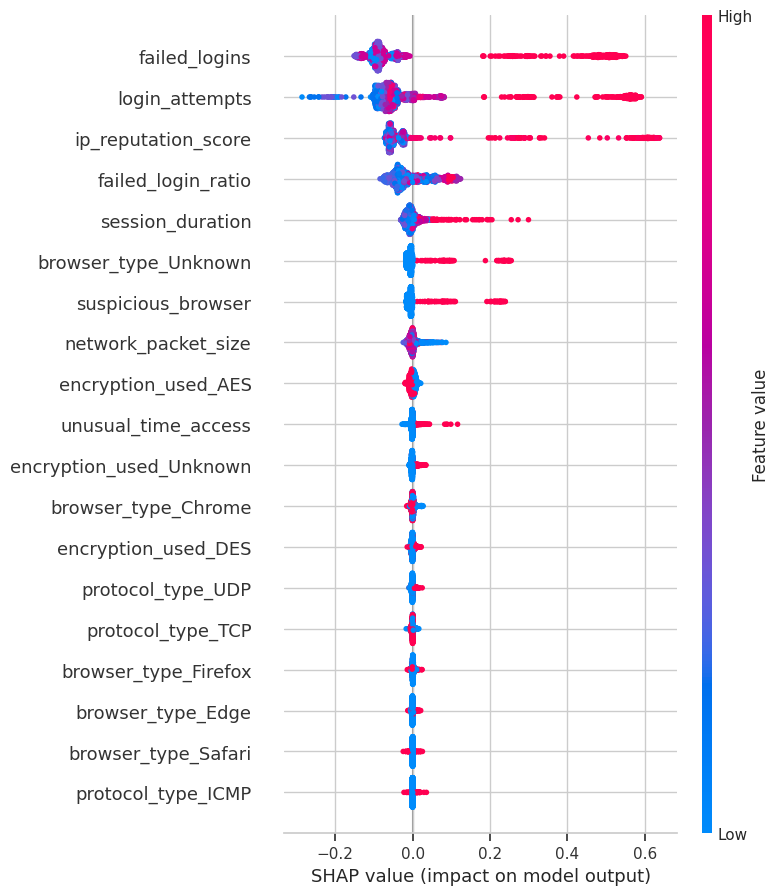

In [ ]:
import shap

rf_pipeline = models["Random Forest (tuned)"]
rf_clf = rf_pipeline.named_steps["clf"]
X_test_transformed = rf_pipeline.named_steps["prep"].transform(X_test)

ohe = rf_pipeline.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values[:, :, 1], X_test_transformed,
    feature_names=feature_names, show=False
)
plt.tight_layout()
plt.show()

## 14. Training and Testing Time (Real-Time Deployment Considerations)

Accuracy alone does not determine whether a model is suitable for a real-time intrusion detection system. A detector sitting in an authentication path must return a decision quickly. This section consolidates the training and testing (inference) time recorded for all six models.

In [ ]:
timing_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (tuned)", "K-Means", "Isolation Forest",
              "MLP (Deep Learning)", "Autoencoder (Deep Learning)"],
    "Train time (s)": [lr_train_time, rf_train_time, kmeans_train_time, iso_train_time,
                        mlp_train_time, ae_train_time],
    "Test time (s)": [None, None, kmeans_test_time, iso_test_time, mlp_test_time, ae_test_time],
})

# Supervised classical models' test time: measure directly here for completeness
t0 = time.perf_counter()
_ = models["Logistic Regression"].predict(X_test)
lr_test_time = time.perf_counter() - t0
t0 = time.perf_counter()
_ = models["Random Forest (tuned)"].predict(X_test)
rf_test_time = time.perf_counter() - t0

timing_summary.loc[timing_summary["Model"] == "Logistic Regression", "Test time (s)"] = lr_test_time
timing_summary.loc[timing_summary["Model"] == "Random Forest (tuned)", "Test time (s)"] = rf_test_time

timing_summary = timing_summary.round(4)
timing_summary

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.barh(timing_summary["Model"], timing_summary["Test time (s)"], color="#4C72B0")
plt.xlabel("Test time on 1,908 sessions (seconds)")
plt.title("Inference Time by Model")
plt.tight_layout()
plt.show()

The two deep learning models are the slowest at inference by a wide margin, despite the MLP's accuracy being statistically indistinguishable from Random Forest's. Random Forest's training time is the highest overall, driven entirely by the `RandomizedSearchCV` hyperparameter search -- but that cost is paid once, offline, and does not affect deployment latency, unlike its test time, which is what a live system would actually experience per batch of sessions. Since Random Forest matches the MLP's accuracy while testing substantially faster, there is no accuracy-for-latency trade-off here that would justify the deep learning model in a real-time deployment -- the classical method dominates on both axes simultaneously.